<a href="https://colab.research.google.com/github/TechJas/CAFE-DATA-ANALYSIS/blob/main/cafe_sales_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [523]:
import kagglehub
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.


In [524]:
import os
path = os.path.join(path,'dirty_cafe_sales.csv')


In [525]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [526]:
df = pd.read_csv(path)
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [527]:
df.shape

(10000, 8)

In [528]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


Checks whether null values present or not

In [529]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [530]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [531]:
df['Total Spent'].isna().sum()

np.int64(173)

In [532]:
df['Total Spent'].unique()

array(['4.0', '12.0', 'ERROR', '10.0', '20.0', '9.0', '16.0', '15.0',
       '25.0', '8.0', '5.0', '3.0', '6.0', nan, 'UNKNOWN', '2.0', '1.0',
       '7.5', '4.5', '1.5'], dtype=object)

In [533]:
df['Total Spent'].shape

(10000,)

In [534]:
invalid_percent = df['Total Spent'].isna().sum()/len(df['Total Spent']) * 100
print(invalid_percent)

1.73


Instead of dropping, I reconstructed missing values using available features to preserve data integrity.

In [535]:
df['Total Spent']= pd.to_numeric(df['Total Spent'],errors = 'coerce')

In [536]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors = 'coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors = 'coerce')
df["Total Spent"] = df["Total Spent"].fillna(
  df["Quantity"] * df["Price Per Unit"]
)

## **FIXING INVALID DATE FORMAT**

In [537]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors = 'coerce')

In [538]:
df[df['Transaction Date'].isna()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
11,TXN_3051279,Sandwich,2.0,4.0,8.0,Credit Card,Takeaway,NaT
29,TXN_7640952,Cake,4.0,3.0,12.0,Digital Wallet,Takeaway,NaT
33,TXN_7710508,UNKNOWN,5.0,1.0,5.0,Cash,NaN,NaT
77,TXN_2091733,Salad,1.0,5.0,5.0,NaN,In-store,NaT
103,TXN_7028009,Cake,4.0,3.0,12.0,NaN,Takeaway,NaT
...,...,...,...,...,...,...,...,...
9933,TXN_9460419,Cake,1.0,3.0,3.0,NaN,Takeaway,NaT
9937,TXN_8253472,Cake,1.0,3.0,3.0,NaN,NaN,NaT
9949,TXN_3130865,Juice,3.0,3.0,9.0,NaN,In-store,NaT
9983,TXN_9226047,Smoothie,3.0,4.0,12.0,Cash,NaN,NaT


Total rows in transaction date = 10000

columns = 8

invalid rows = 460

percentage of bad rows = 4.6 %

4.6 % is lesser than 5 % , so it is allow to drop the null values


In [539]:
df = df.dropna(subset = ['Transaction Date'])

In [540]:
#creating new feature for unlocking sales analysis on basis of month , day and year
df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day

#   Quantity Analysis

In [541]:
df['Quantity'].unique()

array([ 2.,  4.,  5.,  3.,  1., nan])

In [542]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors = 'coerce')

In [543]:
df['Quantity'].isna().sum()

np.int64(454)

Total rows = 10000

invalid rows in quantity = 454

percentage of bad rows = 4.54%

it is alowed to drop null values

In [544]:
df = df.dropna(subset = ['Quantity'])

In [545]:
df['Quantity'].isnull().sum()


np.int64(0)

In [546]:
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_quantity = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")

print("\nOutliers in Quantity column:",outliers_quantity.shape)



#no outlier in qunatity column

Q1 (25th percentile): 2.0
Q3 (75th percentile): 4.0
IQR (Interquartile Range): 2.0
Lower Bound for Outliers: -1.0
Upper Bound for Outliers: 7.0

Outliers in Quantity column: (0, 11)


Convert Price per unit and total spent are numeric forms

In [547]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

In [549]:
df['Price Per Unit'].isna().sum()

np.int64(490)

In [550]:
#null values in price per unit is removed
df = df.dropna(subset = ['Price Per Unit'])


In [551]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan],
      dtype=object)

In [552]:
valid_methods = ['Credit Card', 'Cash', 'Digital Wallet']

df.loc[~df['Payment Method'].isin(valid_methods), 'Payment Method'] = None

In [553]:
df['Payment Method'].value_counts()

,count
Payment Method,
Digital Wallet,1980
Cash,1957
Credit Card,1955


Invalid payment methods were replaced with null values, and rows containing null values were removed using dropna() to ensure only valid transactions were included in the analysis.

In [554]:
df.dropna(subset = ['Payment Method'], inplace = True)

In [555]:
#Revenue Per Payment Method

payment_revenue = df.groupby('Payment Method')['Total Spent'].sum()
payment_revenue

,Total Spent
Payment Method,
Cash,17738.5
Credit Card,17550.5
Digital Wallet,17711.0


In [556]:
df['Month']

,Month
0,9
1,5
2,7
4,6
5,3
...,...
9990,5
9991,2
9993,10
9997,3


In [557]:
'''unlocking peak Sales month  '''
#Calculate Total Sales Per Month

monthly_sales  = df.groupby('Month')['Total Spent'].sum()

In [558]:
print("Highest Sales Month : ", monthly_sales.idxmax())

Highest Sales Month :  6


In [559]:
print(monthly_sales)

Month
1     4526.5
2     4156.0
3     4457.0
4     4268.0
5     3999.5
6     4618.0
7     4333.0
8     4584.0
9     4578.0
10    4496.5
11    4567.5
12    4416.0
Name: Total Spent, dtype: float64


In [560]:
# Quantity sold per month
monthly_quantity = df.groupby('Month')['Quantity'].sum().sort_values(ascending=False)
print(monthly_quantity)

Month
10    1561.0
11    1542.0
9     1540.0
8     1537.0
6     1527.0
3     1516.0
1     1510.0
12    1467.0
7     1442.0
4     1427.0
2     1385.0
5     1349.0
Name: Quantity, dtype: float64


<Axes: xlabel='Month'>

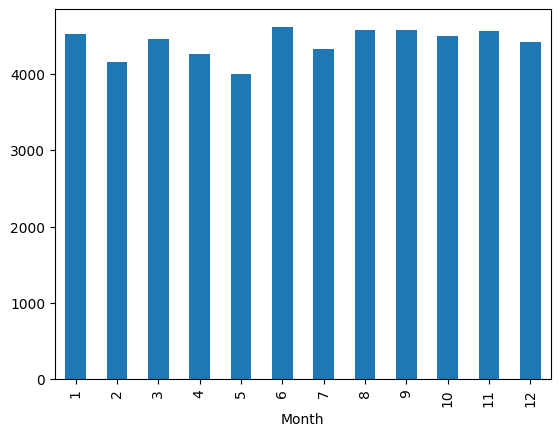

In [561]:
monthly_sales.plot(kind = 'bar')

In [562]:
yearly_sales =df.groupby('Year')['Total Spent'].sum()

In [563]:
print(yearly_sales)

Year
2023    53000.0
Name: Total Spent, dtype: float64


5️⃣ Time-Based Analysis

Daily / weekly trends:

In [564]:
df['Day'] = df['Transaction Date'].dt.day_name()
daily_revenue = df.groupby('Day')['Total Spent'].sum().sort_values(ascending=False) #descending order based sorted and
print(daily_revenue)

Day
Monday       7910.5
Tuesday      7752.5
Sunday       7662.5
Thursday     7540.0
Friday       7525.5
Saturday     7468.0
Wednesday    7141.0
Name: Total Spent, dtype: float64


identified : on monday, large revenue generated

In [565]:
#1️⃣ Total Sales Analysis

"""Find total revenue generated."""
total_sales = df['Total Spent'].sum()
print(total_sales)

53000.0


In [566]:
df['Item'].isnull().sum()

np.int64(194)

In [567]:
df['Item'].value_counts(ascending = False)

,count
Item,
Juice,728
Salad,703
Cake,682
Sandwich,651
Coffee,649
Cookie,646
Smoothie,644
Tea,616
UNKNOWN,198


In [568]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Smoothie', 'Sandwich', 'Salad',
       'Juice', nan, 'UNKNOWN', 'ERROR', 'Tea'], dtype=object)

In [569]:
validity = [ 'Coffee', 'Cake', 'Cookie', 'Smoothie', 'Sandwich', 'Salad',
       'Juice', 'Tea']

df.loc[~df['Item'].isin(validity), 'Item'] = None

194 invalid rows in items
percent of bad rows = 1.94
and allows to drop

In [570]:
df.dropna(subset = ['Item'], inplace = True)

In [571]:
df["Item"].value_counts()

,count
Item,
Juice,728
Salad,703
Cake,682
Sandwich,651
Coffee,649
Cookie,646
Smoothie,644
Tea,616


In [572]:
#3️⃣ Most Sold Item. Find which product sells the most.
"""Infers  : Shows popular products."""
items_bought = df.groupby('Item')['Quantity'].sum()   #ascending order basis sorted
print(items_bought)

Item
Cake        2100.0
Coffee      1964.0
Cookie      1917.0
Juice       2138.0
Salad       2112.0
Sandwich    1982.0
Smoothie    1992.0
Tea         1884.0
Name: Quantity, dtype: float64


In [573]:
#Revenue by item
item_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending = False)
print(item_revenue)

Item
Salad       10560.0
Smoothie     7968.0
Sandwich     7928.0
Juice        6414.0
Cake         6300.0
Coffee       3928.0
Tea          2826.0
Cookie       1917.0
Name: Total Spent, dtype: float64


In [574]:
#5️⃣ Location-Based Sales
df['Location'].isnull().sum()

np.int64(1706)

In [575]:
df['Location'].unique()

array(['Takeaway', 'In-store', nan, 'UNKNOWN', 'ERROR'], dtype=object)

In [576]:
val = ['Takeaway', 'In-store']
df.loc[~df['Location'].isin(val), 'Location'] = None

In [577]:
df['Location'].value_counts()

,count
Location,
Takeaway,1618
In-store,1616


17% INVALID ROWS IN LOCATION COLUMNS PERCENTS


allow to drop since it is not critical.

In [578]:
df.dropna(subset=['Location'],inplace = True)

✅Insight:

Which item is most popular in each month

Detect seasonal patterns in item sales (like smoothies in summer, coffee in winter)

In [579]:
item_month = df.pivot_table(values='Quantity', index='Item', columns='Month', aggfunc='sum')
print(item_month)

Month        1      2      3      4      5      6      7      8      9   \
Item                                                                      
Cake      146.0   84.0   78.0   88.0   71.0   95.0  104.0  119.0  102.0   
Coffee     92.0   93.0   98.0   93.0   79.0  107.0  126.0   74.0   64.0   
Cookie    121.0   91.0  108.0   76.0  107.0   89.0  105.0  102.0  110.0   
Juice     123.0  117.0   91.0  126.0  104.0  103.0   75.0  102.0  104.0   
Salad     122.0   95.0  120.0  124.0   67.0  113.0  113.0  122.0   95.0   
Sandwich  183.0   96.0   84.0   98.0   89.0  102.0  116.0   89.0  138.0   
Smoothie   70.0   94.0   99.0   85.0   77.0  101.0   79.0   84.0  131.0   
Tea       100.0  120.0  108.0  115.0   91.0   86.0   84.0   89.0  101.0   

Month        10     11     12  
Item                           
Cake      132.0  134.0   70.0  
Coffee    133.0   84.0  124.0  
Cookie    114.0  107.0   99.0  
Juice     120.0  122.0  108.0  
Salad      94.0  147.0  118.0  
Sandwich   82.0   88.0   

3️⃣ Payment Method Analysis

Insight:

Understand which payment method is more popular month-wise

Track if customers prefer cash vs digital in certain months

In [580]:
payment_month = df.pivot_table(values='Total Spent', index='Payment Method', columns='Month', aggfunc='sum')
print(payment_month)

Month               1      2      3      4      5      6      7      8   \
Payment Method                                                            
Cash             933.5  787.5  846.5  808.0  607.5  750.5  922.5  765.5   
Credit Card     1027.0  768.5  702.0  806.5  600.5  811.5  702.0  788.5   
Digital Wallet   923.5  739.0  756.5  814.0  717.5  841.0  740.5  794.5   

Month              9       10      11     12  
Payment Method                                
Cash            877.5   676.0   849.5  740.0  
Credit Card     731.5   699.5   776.0  823.0  
Digital Wallet  949.5  1036.0  1038.0  810.0  


📍 Combined Analysis

Top items contributing to revenue per month:


You can plot a stacked bar chart for months showing contribution of each item to revenue.

In [581]:
item_revenue_month = df.pivot_table(values='Total Spent', index='Item', columns='Month', aggfunc='sum')
print(item_revenue_month)

Month        1      2      3      4      5      6      7      8      9   \
Item                                                                      
Cake      438.0  252.0  234.0  264.0  213.0  285.0  312.0  357.0  306.0   
Coffee    184.0  186.0  196.0  186.0  158.0  214.0  252.0  148.0  128.0   
Cookie    121.0   91.0  108.0   76.0  107.0   89.0  105.0  102.0  110.0   
Juice     369.0  351.0  273.0  378.0  312.0  309.0  225.0  306.0  312.0   
Salad     610.0  475.0  600.0  620.0  335.0  565.0  565.0  610.0  475.0   
Sandwich  732.0  384.0  336.0  392.0  356.0  408.0  464.0  356.0  552.0   
Smoothie  280.0  376.0  396.0  340.0  308.0  404.0  316.0  336.0  524.0   
Tea       150.0  180.0  162.0  172.5  136.5  129.0  126.0  133.5  151.5   

Month        10     11     12  
Item                           
Cake      396.0  402.0  210.0  
Coffee    266.0  168.0  248.0  
Cookie    114.0  107.0   99.0  
Juice     360.0  366.0  324.0  
Salad     470.0  735.0  590.0  
Sandwich  328.0  352.0  3

7️⃣ Cross Analysis

✅ Insight: identify which item sells better via which channel.

In [582]:
#Revenue by item and location:
item_location = df.pivot_table(values='Total Spent', index='Item', columns='Location', aggfunc='sum')


#Quantity by item and payment method:

item_payment = df.pivot_table(values='Quantity', index='Item', columns='Payment Method', aggfunc='sum')



print(item_location)
print("\n")
print(item_payment)

Location  In-store  Takeaway
Item                        
Cake        1776.0    1893.0
Coffee      1058.0    1276.0
Cookie       558.0     671.0
Juice       2079.0    1806.0
Salad       3575.0    3075.0
Sandwich    2688.0    2352.0
Smoothie    2172.0    2188.0
Tea          901.5     892.5


Payment Method   Cash  Credit Card  Digital Wallet
Item                                              
Cake            424.0        420.0           379.0
Coffee          394.0        356.0           417.0
Cookie          425.0        399.0           405.0
Juice           418.0        379.0           498.0
Salad           438.0        454.0           438.0
Sandwich        431.0        367.0           462.0
Smoothie        338.0        348.0           404.0
Tea             373.0        399.0           424.0


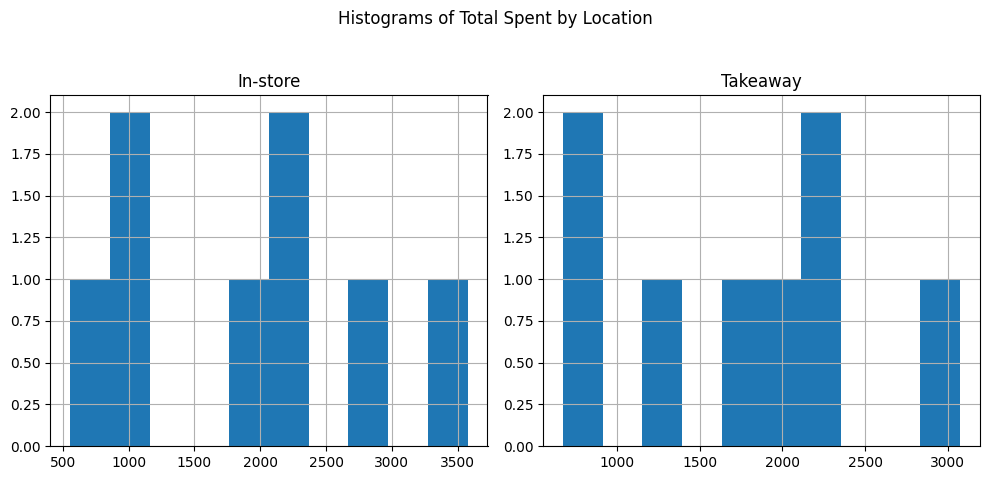

In [583]:
item_location.hist(figsize=(10, 5))
plt.suptitle('Histograms of Total Spent by Location')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

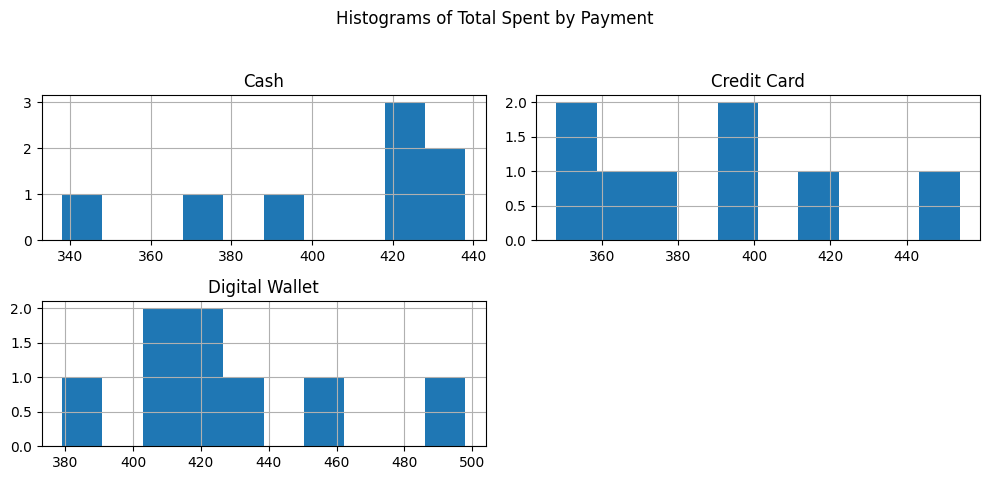

In [584]:
item_payment.hist(figsize=(10, 5))
plt.suptitle('Histograms of Total Spent by Payment')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **A time-series forecasting model to predict future café sales using historical transaction data.**

Create Daily Sales Dataset

ML won’t work on raw transactions.

In [592]:
df_daily = df.groupby("Transaction Date")["Total Spent"].sum().reset_index()

df_daily["Transaction Date"] = pd.to_datetime(df_daily["Transaction Date"])
df_daily = df_daily.sort_values("Transaction Date")

df_daily.set_index("Transaction Date", inplace=True)

In [594]:
df_daily['Day'] = range(len(df_daily))

train_size = int(len(df_daily) * 0.8)

train = df_daily[:train_size]
test = df_daily[train_size:]

X_train = train[["Day"]]
y_train = train["Total Spent"]

X_test = test[["Day"]]
y_test = test["Total Spent"]

In [595]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [596]:
y_pred = model.predict(X_test)

In [597]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 26.906927301006924


In [598]:
future_days = pd.DataFrame({
    "Day": range(len(df_daily), len(df_daily) + 30)
})

future_predictions = model.predict(future_days)

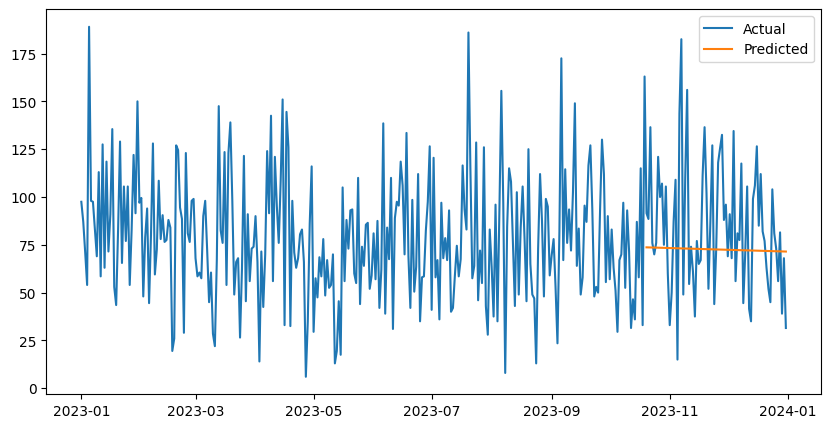

In [599]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_daily.index, df_daily["Total Spent"], label="Actual")
plt.plot(test.index, y_pred, label="Predicted")

plt.legend()
plt.show()

👉 Yesterday’s sales → predict today

In [600]:
df_daily["Lag1"] = df_daily["Total Spent"].shift(1)

👉 Captures weekly trend

In [601]:
df_daily["RollingMean7"] = df_daily["Total Spent"].rolling(7).mean()

In [602]:
df_daily = df_daily.dropna()

train again

In [605]:
X1 = df_daily[["Day", "Lag1", "RollingMean7"]]
y1 = df_daily["Total Spent"]

**Model** **Observation**:

The initial linear regression model captured only the overall trend and failed to model fluctuations due to limited features.

**Improvement:**

Additional lag and rolling features were introduced to incorporate temporal dependencies and improve prediction quality.

Train MODEL with new features.

In [607]:
from sklearn.linear_model import LinearRegression

X = df_daily[["Day", "Lag1", "RollingMean7"]]
y = df_daily["Total Spent"]

# Split again
train_size = int(len(df_daily) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [608]:
y_pred_new = model.predict(X_test)

In [609]:
from sklearn.metrics import mean_absolute_error

mae_new = mean_absolute_error(y_test, y_pred_new)

print("Improved MAE:", mae_new)

Improved MAE: 26.852733782236378


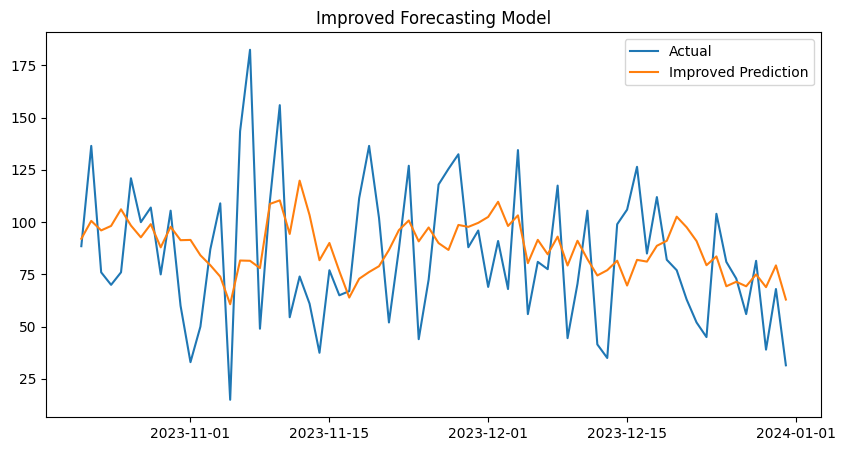

In [610]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_new, label="Improved Prediction")

plt.legend()
plt.title("Improved Forecasting Model")
plt.show()

future prediction

In [611]:
future_days = 30
last_day = df_daily["Day"].iloc[-1]

future_df = pd.DataFrame({
    "Day": range(last_day + 1, last_day + future_days + 1),
    "Lag1": df_daily["Total Spent"].iloc[-1],
    "RollingMean7": df_daily["RollingMean7"].iloc[-1]
})

future_pred = model.predict(future_df)

🔹 Model Comparison

Baseline Model:

Used only time index
Captured overall trend
Failed to capture fluctuations

Improved Model:

Added Lag and Rolling features
Captured short-term patterns
Improved prediction accuracy

🔹 Conclusion

The initial model was limited in capturing fluctuations due to lack of temporal features. After introducing lag and rolling mean features, the model improved in tracking sales patterns, demonstrating the importance of feature engineering in time-series forecasting.